In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("09-exercise-pids2026.ipynb")

<div style='background:linear-gradient(135deg,#D7E6FF 0%,#C2D9FF 100%); padding:28px 32px; border-radius:10px; color:black; font-family:Arial,sans-serif;'>
  <div style='display:flex; align-items:center; gap:18px;'>
    <span style='font-size:3em;'>📊</span>
    <div>
      <h1 style='margin:0; font-size:1.8em; letter-spacing:1px;'>Exercise Sheet 9</h1>
      <p style='margin:4px 0 0; font-size:1em; opacity:0.85;'>
        Practical Introduction to Data Science · University of Basel · Spring 2026</p>
    </div>
  </div>
  <hr style='border:none; border-top:1px solid rgba(255,255,255,0.3); margin:18px 0 14px;'>
  <div style='display:flex; gap:28px; font-size:0.92em; opacity:0.9;'>
    <span>🔬 P-Values </span>
    <span>📈 Correlations </span>
    <span>📏 Regression </span>
    <span>🎯 15 Points</span>
  </div>
</div>

**Hello everyone!**

**Points: 15**

Topics of this exercise sheet are:
* P-Values
* Correlations

Please let us know if you have questions or problems! <br>
Contact us during the exercise session or on [Piazza](https://piazza.com/class/mlq9993zjlh6sm#).

**Automatic Feedback**

This notebook can be automatically graded using Otter grader. To find how many points you get, simply run `grader.check_all()` from a new cell. 

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy.stats import norm

![Basel](Basel.jpg)

# Basel's neighborhoods
We are working with a dataset containing information about Basel and its neighborhoods. You can find it here: https://opendata.swiss/de/dataset/kennzahlen-zu-den-basler-wohnvierteln-und-landgemeinden. It's also uploaded as a csv to this folder.

In [3]:
bs = pd.read_csv("basel_neighborhoods.csv", sep=";")
bs.head()

,Publikationsjahr,Wohnviertel ID,Wohnviertel Name,Altersquotient,Jugendquotient,Anteil Personen ohne Religionszugehörigkeit,Anteil Personen in Einpersonenhaushalten,Anteil Sesshafte,Baujahr der Wohngebäude,Anteil Einfamilienhäuser,...,Anteil Sozialhilfeempfänger,Anteil Ausländer,Anteil Grünflächen,Fläche pro Wohnung,Wohnfläche pro Person,Vermögenssteuer pro Veranlagung,Einkommenssteuer pro Veranlagung,Erwerbstätigenquote,Arbeitsplätze pro Einwohner,Arbeitslosenquote
0,2015,3,Am Ring,0.360148,0.207675,0.488232,0.300021,0.305592,1918.383233,0.198460,...,0.038411,0.340331,0.239018,82.343801,47.311517,2378.931266,10820.800512,0.807728,0.990658,0.025282
1,2015,5,St. Alban,0.490177,0.277967,0.472360,0.251193,0.347475,1938.667504,0.340034,...,0.032415,0.308540,0.322732,93.782306,49.809694,3839.555889,15620.768077,0.728933,2.196454,0.029765
2,2015,7,Bruderholz,0.442465,0.370422,0.458660,0.166817,0.427310,1948.410577,0.734615,...,0.017662,0.229827,0.713769,109.383218,50.067809,8585.686671,18103.101406,0.752834,0.130144,0.023127
3,2015,13,Clara,0.313625,0.179214,0.474293,0.270094,0.309963,1928.330769,0.019231,...,0.089053,0.464699,0.157663,67.319444,37.293003,404.341988,6221.222312,0.664063,0.664847,0.049137
4,2015,17,Matthäus,0.165117,0.220981,0.446714,0.241082,0.282304,1924.815303,0.071240,...,0.127677,0.516121,0.167294,67.381837,34.554332,419.033825,6202.489730,0.675245,0.188245,0.051271


## Question 1) P value (10 points)
Let's see if there's an answer to the following question: Did the amount of green spaces in Basel's neighborhoods increase *significantly* between 2015 and 2025? <br>

The column that measures the amount of green spaces (parks and such) is called `Anteil Grünflächen`.

### 1a) Observed difference (1 point)
What is the observed difference between the mean of the amount of green spaces in 2015 and in 2025? <br>
Assign the mean of the amount of green spaces for the years 2015 and 2025 to the variables `mean_2015` and `mean_2025` respectively.

*Hint:* You can average over all neighborhoods

In [4]:
class Question1a:
    mean_2015 = bs[bs["Publikationsjahr"] == 2015]["Anteil Grünflächen"].mean() # SOLUTION
    mean_2025 = bs[bs["Publikationsjahr"] == 2025]["Anteil Grünflächen"].mean() # SOLUTION

    
    print(mean_2025 - mean_2015)

0.011619709442857062


In [5]:
grader.check("Question 1a")

Question 1a results: All test cases passed!

### 1b) Artificial variables (3 points)
Let us make a new dataframe called: 
- `neighborhoods` 
  - This new dataframe contains the neighborhoods of Basel in a column called `Wohnviertel Name.` Additionally, it should have a column called `increase_green_space` that has 
      - the number 1 if the amount of green space increased between 2015 and 2025 for this neighborhood
      - the number 0 otherwise
      
*More formally:*
$$
  \begin{equation}
    increase\_green\_space=
    \begin{cases}
      1, & \text{if}\ \text{Anteil Grünflächen}_{2025}[x] > \text{Anteil Grünflächen}_{2015}[x], x \in \text{Wohnviertel Name}  \\
      0, & \text{otherwise}
    \end{cases}
  \end{equation}
$$
**Hints:** 
- Spread the data into two new dataframes: `bs_2025` and `bs_2015`. `bs_2025` will also be reused in this exercise sheet's last exercise.
- Create from `bs_2025` and `bs_2015` a merged dataframe on the column `Wohnviertel Name` and use the `suffixes=(2025,2015)` option 

In [6]:
class Question1b:
    # BEGIN SOLUTION
    bs_2015 = bs.loc[bs["Publikationsjahr"] == 2015].copy()
    bs_2025 = bs.loc[bs["Publikationsjahr"] == 2025].copy()

    neighborhoods = pd.merge(bs_2025, bs_2015, on = "Wohnviertel Name", suffixes=(2025,2015))

    neighborhoods["increase_green_space"] = 0
    neighborhoods.loc[neighborhoods["Anteil Grünflächen2015"] < neighborhoods["Anteil Grünflächen2025"], "increase_green_space"] = 1
    # END SOLUTION

    display(neighborhoods.head())

,Publikationsjahr2025,Wohnviertel ID2025,Wohnviertel Name,Altersquotient2025,Jugendquotient2025,Anteil Personen ohne Religionszugehörigkeit2025,Anteil Personen in Einpersonenhaushalten2025,Anteil Sesshafte2025,Baujahr der Wohngebäude2025,Anteil Einfamilienhäuser2025,...,Anteil Ausländer2015,Anteil Grünflächen2015,Fläche pro Wohnung2015,Wohnfläche pro Person2015,Vermögenssteuer pro Veranlagung2015,Einkommenssteuer pro Veranlagung2015,Erwerbstätigenquote2015,Arbeitsplätze pro Einwohner2015,Arbeitslosenquote2015,increase_green_space
0,2025,3,Am Ring,0.300214,0.232372,NaN,0.268872,0.284768,1921.081240,0.192630,...,0.340331,0.239018,82.343801,47.311517,2378.931266,10820.800512,0.807728,0.990658,0.025282,1
1,2025,4,Breite,0.308544,0.232689,NaN,0.283522,0.318465,1942.762048,0.129518,...,0.319305,0.358597,69.810769,39.026379,483.026818,7123.858168,0.732465,0.140373,0.046666,1
2,2025,7,Bruderholz,0.403930,0.411676,NaN,0.143159,0.426015,1950.297963,0.721459,...,0.229827,0.713769,109.383218,50.067809,8585.686671,18103.101406,0.752834,0.130144,0.023127,0
3,2025,8,Bachletten,0.378242,0.321931,NaN,0.216490,0.408556,1934.651376,0.557240,...,0.210320,0.408619,93.179580,47.396467,1632.650810,11363.577884,0.790006,0.190061,0.023636,1
4,2025,19,Kleinhüningen,0.335511,0.312352,NaN,0.220112,0.348468,1947.964497,0.153846,...,0.456885,0.095810,70.502959,32.888446,192.433640,4771.427727,0.660175,1.652422,0.057516,1


In [7]:
grader.check("Question 1b")

Question 1b results: All test cases passed!

### 1c) Amount of neighborhoods with an increase in green spaces (2 points)

We want to verify if there was an increase or decrease in green spaces. For this, we work under the null hypothesis:
$$ \mathbb{P}(\text{green spaces increase}) -0.5 = 0. $$


What is the percentage of neighborhoods that had increased green spaces from 2015 to 2025? Save this decimal number (float) in the variable called `increase_2025`. <br>
This value will let us calculate the difference to our null hypothesis value since it is our $ \mathbb{P}(\text{green spaces increase})$. Assign the difference of `increase_2025` to our null hypothesis value (0.5) to the variable called `difference_null_hypothesis` (float).

In [ ]:
class Question1c:
    increase_2025 = Question1b.neighborhoods["increase_green_space"].mean() # SOLUTION
    difference_null_hypothesis = increase_2025 - 0.5 # SOLUTION
    print(increase_2025, difference_null_hypothesis)

NameError: name 'Question1b' is not defined

: 

In [ ]:
grader.check("Question 1c")

Question 1c results: All test cases passed!

### 1d) Calculate the p-value (3 points)
What is the p-value for the significant difference in green space between 2015 and 2025? In other words: What is the p-value for: 
$$
\begin{align*}
P(|mean2025 - 0.5| > \text{observed\_difference})
\end{align*}
$$

Assign the p-value to the variable called `p_value`

*Hint:* Look at the slides from lecture 9 to find an example.

In [10]:
class Question1d:
    # BEGIN SOLUTION
    N = bs[bs["Publikationsjahr"] == 2025]["Anteil Grünflächen"].count()
    t = np.sqrt(N) * Question1c.difference_null_hypothesis/0.5
    # END SOLUTION

    # only works since t > 0, otherwise use abs(t)
    p_value = ((1 - (norm.cdf(t) - norm.cdf(-t)))) # SOLUTION
    print("The p-value is: ", p_value)

The p-value is:  0.049534613435626706


In [11]:
grader.check("Question 1d")

Question 1d results: All test cases passed!

### 1e) Do we reject or fail to reject the null hypothesis based on our p value? (1 point)
Here our significance value is 0.05.

Please write your answer like this:
* If we reject the null hypothesis: null_hypothesis = "reject"
* If we can not reject the null hypothesis: null_hypothesis = "fail to reject"

(Hint: Read the question carefully and google it if you're not sure what it means)

### Answer:
* The p-value is smaller than the significance level, therefore we reject the null hypothesis.

<!-- BEGIN QUESTION -->

<!--
BEGIN QUESTION
name: Question 1e      # (required) the path to a requirements.txt file
manual: true     # whether this is a manually-graded question
points: 1      # how many points this question is worth; defaults to 1 internally
check_cell: false  # whether to include a check cell after this question (for autograded questions only)
-->

In [12]:
class Question1e:
    null_hypothesis = "reject"

In [13]:
grader.check("Question 1e")

Question 1e results:
    Question 1e - 1 result:
        ❌ Test case failed
        Error at line 11 in test Question 1e:
             assert False, "***We will grade this question only after submission, in order not to reveal the answer***"
        AssertionError: ***We will grade this question only after submission, in order not to reveal the answer***

<!-- END QUESTION -->



## Question 2) Correlation and regression (5 points)

### 2a) Plotting the correlation (2 points)
Make a scatterplot **using pandas plotting** function that shows you how income tax `Einkommenssteuer pro Veranlagung` and apartment size `Fläche pro Wohnung` are correlated. 

Plot **for the year 2025**: 
- `Einkommenssteuer pro Veranlagung` on the *x*-axis and  
- `Fläche pro Wohnung` on the *y*-axis.

<!-- BEGIN QUESTION -->

<!--
BEGIN QUESTION
name: Question 2a      # (required) the path to a requirements.txt file
manual: true     # whether this is a manually-graded question
points: 2     # how many points this question is worth; defaults to 1 internally
check_cell: false  # whether to include a check cell after this question (for autograded questions only)
-->

<Axes: xlabel='Einkommenssteuer pro Veranlagung', ylabel='Fläche pro Wohnung'>

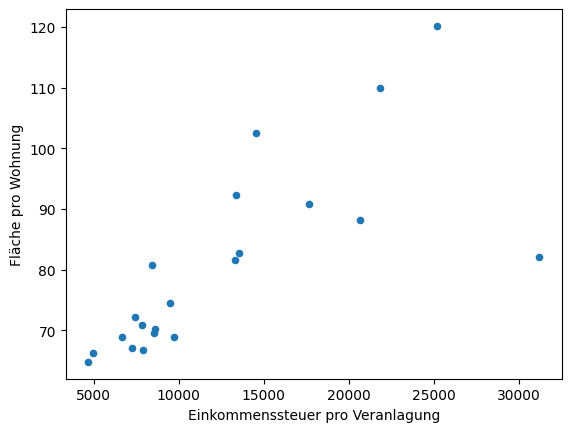

In [14]:
class Question2a:
    # BEGIN SOLUTION
    bs_2025 = Question1b.bs_2025
    corr_plot = bs_2025.plot.scatter("Einkommenssteuer pro Veranlagung", "Fläche pro Wohnung")  # your scatter plot
    # END SOLUTION
    display(corr_plot)

In [15]:
grader.check("Question 2a")

Question 2a results: All test cases passed!

<!-- END QUESTION -->



### 2b) Correlation coefficient (1 point)
What is the correlation coefficient between income tax and apartments size in Basel for 2025? Assign this number (float) to the variable called `corr_coeff`.

*Hint:* pandas.dataframe has a function called `.corr()`

In [16]:
class Question2b:
    corr_coeff = Question1b.bs_2025["Einkommenssteuer pro Veranlagung"].corr(Question1b.bs_2025["Fläche pro Wohnung"]) # SOLUTION
    print("correlation coefficient: ", corr_coeff)

correlation coefficient:  0.7457757498901518


In [17]:
grader.check("Question 2b")

Question 2b results: All test cases passed!

### 2c) Plot another correlation (1 point)
Make a scatter plot **using seaborn** that shows you how living space per person `Wohnfläche pro Person` and apartment size `Fläche pro Wohnung` are correlated **for the year 2025.**

**General Remark:** If you have to plot something on the *x and y axis, always ask yourself: Which variable is dependent on the other?* 

<!-- BEGIN QUESTION -->

<!--
BEGIN QUESTION
name: Question 2c      # (required) the path to a requirements.txt file
manual: true     # whether this is a manually-graded question
points: 1    # how many points this question is worth; defaults to 1 internally
check_cell: false  # whether to include a check cell after this question (for autograded questions only)
-->

<Axes: xlabel='Wohnfläche pro Person', ylabel='Fläche pro Wohnung'>

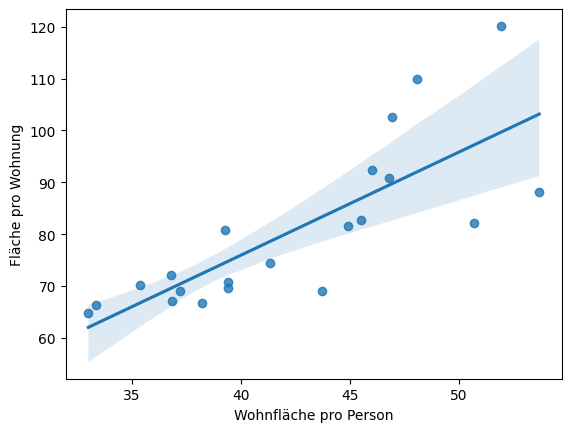

In [18]:
class Question2c:
    corr_plot = sns.regplot(x = Question1b.bs_2025["Wohnfläche pro Person"], y = Question1b.bs_2025["Fläche pro Wohnung"]) # SOLUTION
    display(corr_plot)

In [19]:
grader.check("Question 2c")

Question 2c results: All test cases passed!

<!-- END QUESTION -->



What do you notice on this plot, what kind of correlation do you observe? What could be problematic about this correlation?
Write your answer in the cell below as a comment (use #).

In [20]:
# WRITE DOWN YOUR OBSERVATIONS

# BEGIN SOLUTION
# Possibly a quadratic function, not linear. Outliers might skew regression line.
# END SOLUTION

### 2d) Regression (1 point)

Compute the **slope** `alpha` and **intercept** `beta` of the regression line that relates income tax (predictor) and apartment_size. 

Using the data from the year 2025 `Question1b.bs_2025`. Plot the data and the regression line.


**Reminder:**$ \text{ The regression line is defined as: } f(x) = \alpha x + \beta$
$$
\begin{align*}
&\alpha = corr(x,y) \cdot \frac{\sigma_y}{\sigma_x}, &\text{ } \\
& \beta = \bar{y} - \alpha \cdot \bar{x} \\
& x = \text{tax}, y = \text{appartment size},  \\ 
& \bar{x},\text{ }\bar{y} = \text{arithmetic mean}
\end{align*}
$$ 

*Hints:*
- Make use of the following functions in pandas:  
    - `mean()`
    - `std()`
    - `corr()`

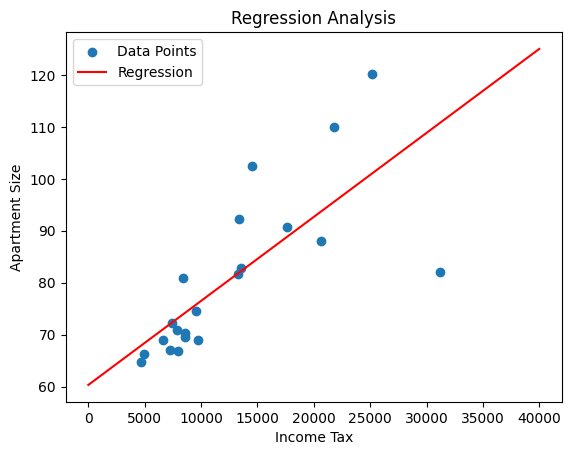

In [21]:
class Question2d:

    # BEGIN SOLUTION
    bs_2025 = Question1b.bs_2025
    
    mean_income_tax = bs_2025["Einkommenssteuer pro Veranlagung"].mean()
    stddev_income_tax = bs_2025["Einkommenssteuer pro Veranlagung"].std()

    mean_apartment_size = bs_2025["Fläche pro Wohnung"].mean()
    stddev_apartment_size = bs_2025["Fläche pro Wohnung"].std()
  
    corr = stats.pearsonr(bs_2025["Einkommenssteuer pro Veranlagung"], bs_2025["Fläche pro Wohnung"])[0]

    alpha = corr*stddev_apartment_size/stddev_income_tax
    beta = mean_apartment_size - mean_income_tax*alpha
    
    x = np.array([i for i in range(0,40000)])
    y = alpha*x + beta
    
    plt.scatter(bs_2025["Einkommenssteuer pro Veranlagung"], Question1b.bs_2025["Fläche pro Wohnung"], label='Data Points')
    plt.plot(x, y, color='red', label='Regression')
    plt.xlabel('Income Tax')
    plt.ylabel('Apartment Size')
    plt.title('Regression Analysis')
    plt.legend()
    plt.show()
    # END SOLUTION

In [22]:
grader.check("Question 2d")

Question 2d results: All test cases passed!

---

To double-check your work, the cell below will rerun all of the autograder tests.

In [23]:
grader.check_all()

Question 1a results: All test cases passed!

Question 1b results: All test cases passed!

Question 1c results: All test cases passed!

Question 1d results: All test cases passed!

Question 1e results:
    Question 1e - 1 result:
        ❌ Test case failed
        Error at line 11 in test Question 1e:
             assert False, "***We will grade this question only after submission, in order not to reveal the answer***"
        AssertionError: ***We will grade this question only after submission, in order not to reveal the answer***

Question 2a results: All test cases passed!

Question 2b results: All test cases passed!

Question 2c results: All test cases passed!

Question 2d results: All test cases passed!